
## 2.1 理论计算题

### 1. 非线性激活函数的重要性

隐藏层：

\[
h = W_1x+b_1
\]

输出层：

\[
o=W_2h+b_2
\]

代入得到：

\[
o=W_2(W_1x+b_1)+b_2
\]

展开：

\[
o=W_2W_1x+W_2b_1+b_2
\]

令：

\[
W' = W_2W_1
\]

\[
b' = W_2b_1+b_2
\]

则：

\[
o=W'x+b'
\]

因此没有激活函数时，多层网络等价于单层线性网络。


### 2. Sigmoid 与 tanh

Sigmoid：

$$
\sigma(x)=\frac{1}{1+e^{-x}}
$$

导数：

$$
\sigma'(x)=\sigma(x)(1-\sigma(x))
$$

导数：

$$
\sigma'(x)=\sigma(x)(1-\sigma(x))
$$  

tanh：

$$
tanh(x)=\frac{e^x-e^{-x}}{e^x+e^{-x}}
$$

导数：

$$
tanh'(x)=1-tanh^2(x)
$$


In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

batch_size = 64

transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

input_size = 784
hidden_size = 256
output_size = 10

W1 = torch.randn(input_size, hidden_size) * 0.01
b1 = torch.zeros(hidden_size)

W2 = torch.randn(hidden_size, output_size) * 0.01
b2 = torch.zeros(output_size)

W1.requires_grad_()
b1.requires_grad_()
W2.requires_grad_()
b2.requires_grad_()

def relu(x):
    return torch.maximum(x, torch.tensor(0.0))

def softmax(x):
    exp_x = torch.exp(x - x.max(dim=1, keepdim=True).values)
    return exp_x / exp_x.sum(dim=1, keepdim=True)

def cross_entropy(y_hat, y):
    return -torch.log(y_hat[range(len(y)), y]).mean()

lr = 0.1

for epoch in range(5):
    total_loss = 0
    
    for X, y in train_loader:
        X = X.reshape(-1, 784)

        h = relu(X @ W1 + b1)
        out = softmax(h @ W2 + b2)

        loss = cross_entropy(out, y)

        loss.backward()

        with torch.no_grad():
            W1 -= lr * W1.grad
            b1 -= lr * b1.grad
            W2 -= lr * W2.grad
            b2 -= lr * b2.grad

            W1.grad.zero_()
            b1.grad.zero_()
            W2.grad.zero_()
            b2.grad.zero_()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss={total_loss:.4f}")


100%|██████████| 26.4M/26.4M [00:27<00:00, 960kB/s] 
100%|██████████| 29.5k/29.5k [00:00<00:00, 52.9kB/s]
100%|██████████| 4.42M/4.42M [00:32<00:00, 136kB/s] 
100%|██████████| 5.15k/5.15k [00:00<?, ?B/s]


Epoch 1, Loss=642.6163
Epoch 2, Loss=419.6685
Epoch 3, Loss=373.3871
Epoch 4, Loss=346.6641
Epoch 5, Loss=328.9932



## 3.1 理论计算题

### 1. 过拟合与欠拟合

训练误差是模型在训练集上的误差。

泛化误差是模型在测试集上的误差。

当训练误差低而泛化误差高时，模型发生了过拟合。

缓解方法：

减少模型复杂度、
Dropout、
增加训练数据、
提前停止训练

### 2. K 折交叉验证

步骤：

1. 将数据集划分为 K 份
2. 每次选择一份作为验证集
3. 剩余 K−1 份作为训练集
4. 重复 K 次
5. 对结果求平均


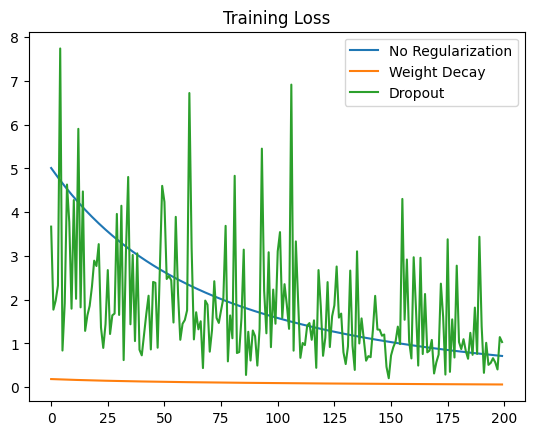

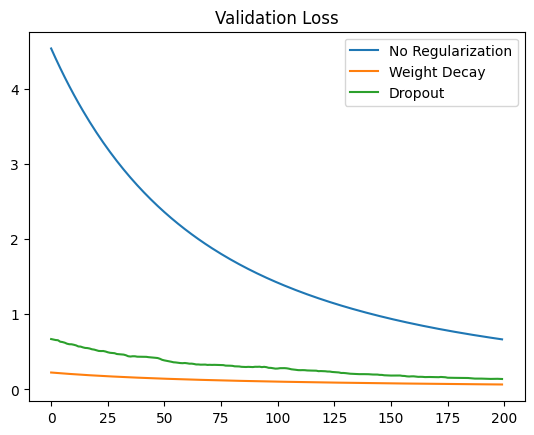

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

x = np.linspace(-1,1,20)
y = x**3 + 0.1*np.random.randn(20)

x_val = np.linspace(-1,1,100)
y_val = x_val**3

def poly_features(x, degree=15):
    return np.vstack([x**i for i in range(degree)]).T

X = poly_features(x)
X_val = poly_features(x_val)

def train(weight_decay=0, dropout=0):
    w = np.random.randn(X.shape[1])

    train_loss = []
    val_loss = []

    for epoch in range(200):

        mask = (np.random.rand(*X.shape) > dropout)/(1-dropout)
        X_drop = X * mask

        pred = X_drop @ w

        grad = X_drop.T @ (pred-y)/len(y)

        w = (1-0.01*weight_decay)*w - 0.01*grad

        train_loss.append(np.mean((pred-y)**2))

        val_pred = X_val @ w
        val_loss.append(np.mean((val_pred-y_val)**2))

    return train_loss, val_loss

t1,v1 = train()
t2,v2 = train(weight_decay=0.1)
t3,v3 = train(dropout=0.5)

plt.plot(t1,label='No Regularization')
plt.plot(t2,label='Weight Decay')
plt.plot(t3,label='Dropout')
plt.legend()
plt.title('Training Loss')
plt.show()

plt.plot(v1,label='No Regularization')
plt.plot(v2,label='Weight Decay')
plt.plot(v3,label='Dropout')
plt.legend()
plt.title('Validation Loss')
plt.show()



## 4.1 理论计算题

### 梯度消失与梯度爆炸

若多层梯度连乘中每层导数小于1，则梯度趋近于0，发生梯度消失。

若每层导数大于1，则梯度指数增长，发生梯度爆炸。

Sigmoid 导数最大仅为0.25，因此容易导致梯度消失。

ReLU 正半轴导数为1，因此能够缓解梯度消失问题。


In [3]:
import torch
import torch.nn as nn

model = nn.Sequential()

for i in range(20):
    model.add_module(f'linear{i}', nn.Linear(256,256))
    model.add_module(f'sigmoid{i}', nn.Sigmoid())

for m in model:
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0, std=1)

x = torch.randn(64,256)
y = model(x).sum()

y.backward()

print("Sigmoid + Normal Init")

for name, param in model.named_parameters():
    if param.grad is not None:
        print(name, param.grad.norm().item())


Sigmoid + Normal Init
linear0.weight 9213.7294921875
linear0.bias 557.87255859375
linear1.weight 5966.60595703125
linear1.bias 552.5296630859375
linear2.weight 4843.8916015625
linear2.bias 439.5600280761719
linear3.weight 4035.679443359375
linear3.bias 364.1806945800781
linear4.weight 3093.8974609375
linear4.bias 293.66162109375
linear5.weight 2362.689697265625
linear5.bias 212.4613494873047
linear6.weight 1740.5673828125
linear6.bias 161.54119873046875
linear7.weight 1356.5318603515625
linear7.bias 124.63634490966797
linear8.weight 907.2174072265625
linear8.bias 84.51759338378906
linear9.weight 856.95703125
linear9.bias 78.76092529296875
linear10.weight 791.151123046875
linear10.bias 73.20063781738281
linear11.weight 590.3446044921875
linear11.bias 56.75908660888672
linear12.weight 517.4769897460938
linear12.bias 47.387603759765625
linear13.weight 494.5289306640625
linear13.bias 45.696083068847656
linear14.weight 511.597412109375
linear14.bias 46.804771423339844
linear15.weight 447.25


## 5.1 理论计算题

### 协变量偏移

$$
p(x)\neq q(x),\quad p(y|x)=q(y|x)
$$

例如：白天训练、夜晚测试。


### 标签偏移

$$
p(y)\neq q(y),\quad p(x|y)=q(x|y)
$$

例如：诈骗用户比例变化。


In [4]:
import numpy as np
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error

np.random.seed(0)

X_train = np.random.normal(-1,1,1000).reshape(-1,1)
y_train = 2*X_train.squeeze() + np.random.randn(1000)*0.1

X_test = np.random.normal(2,1,500).reshape(-1,1)
y_test = 2*X_test.squeeze() + np.random.randn(500)*0.1

model = LinearRegression()
model.fit(X_train,y_train)

pred = model.predict(X_test)

mse1 = mean_squared_error(y_test,pred)

print("Baseline MSE:", mse1)

X_mix = np.vstack([X_train,X_test])
domain = np.hstack([np.zeros(len(X_train)), np.ones(len(X_test))])

clf = LogisticRegression()
clf.fit(X_mix,domain)

p_test = clf.predict_proba(X_train)[:,1]
p_train = 1-p_test

weights = p_test/p_train

model2 = LinearRegression()
model2.fit(X_train,y_train,sample_weight=weights)

pred2 = model2.predict(X_test)

mse2 = mean_squared_error(y_test,pred2)

print("Weighted MSE:", mse2)


Baseline MSE: 0.008844659363669684
Weighted MSE: 0.011101274301897692
